# 03 — Mel-spectrograms and log-mel representations

In the previous notebook, we introduced the STFT and the linear-frequency spectrogram.

In this notebook, we move one step further:

```text
waveform
    ↓
STFT spectrogram
    ↓
frequency-selective analysis
    ↓
mel filter bank
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
```

The main idea is simple:

> A mel-spectrogram summarizes how the energy of an audio signal is distributed across perceptually motivated frequency bands over time.

## Notebook roadmap

We will follow this sequence:

1. Load one ESC-50 audio example.
2. Recall waveform and STFT spectrograms.
3. Explain why a linear frequency axis is not always ideal.
4. Motivate the mel scale using pitch perception.
5. Introduce a bio-inspired intuition: frequency selectivity.
6. Explain filters and filter banks.
7. Visualize mel-spaced filters in Hz and in mel.
8. Build the real triangular mel filter bank used in practice.
9. Compute a mel-spectrogram and log-mel-spectrogram.
10. Connect these image-like representations with machine learning.


## Imports

We will use `librosa` for audio loading and time-frequency representations, `matplotlib` for visualization, and `pandas` for metadata handling.

In [173]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display

## Project paths

We load the same ESC-50 subset used in the previous notebooks.

In [174]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


## Plot style utilities

The notebook uses the shared plotting utilities from `src/plot_config.py`.

Run this cell before the plotting sections so that variables such as `FIGSIZE_WIDE`, `FIGSIZE_TALL`, `DPI`, `GRAYSCALE`, `ACCENT`, and `clean_axes` are available in the kernel.

In [175]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    clean_axes,
    GRAYSCALE,
    ACCENT,
    FIGSIZE_WIDE,
    FIGSIZE_TALL,
    DPI,
)

apply_plot_style()

print("Plot style loaded from:", SRC_DIR / "plot_config.py")

Plot style loaded from: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/src/plot_config.py


### Practical note for Jupyter execution

This notebook uses variables defined in earlier cells.  
For a smooth experience, especially in class, run the notebook from the top or use **Run All** after restarting the kernel.

If a cell complains that variables such as `FIGSIZE_TALL`, `DPI`, or `GRAYSCALE` are not defined, it means the plot-style cell above has not been executed yet.

## Load metadata

The metadata table contains the filename, class label, fold, and relative path for each selected audio file.

In [176]:
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of audio files:", len(metadata))
print("Number of classes:", metadata["category"].nunique())

metadata.head()

Number of audio files: 80
Number of classes: 8


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## Select one audio example

We start with a single example to compare different representations.

In [177]:
selected_category = "sneezing" # "chirping_birds"
example = metadata[metadata["category"] == selected_category].iloc[0]

audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)
duration = librosa.get_duration(y=y, sr=sr)

print("Category:", example["category"])
print("Filename:", example["filename"])
print("Sampling rate:", sr, "Hz")
print("Duration:", duration, "seconds")
print("Number of samples:", len(y))

display(Audio(y, rate=sr))

Category: sneezing
Filename: 1-26143-A-21.wav
Sampling rate: 44100 Hz
Duration: 5.0 seconds
Number of samples: 220500


## Waveform reminder

The waveform shows the amplitude of the signal as a function of time.

It is useful, but it does not directly show which frequencies are present.

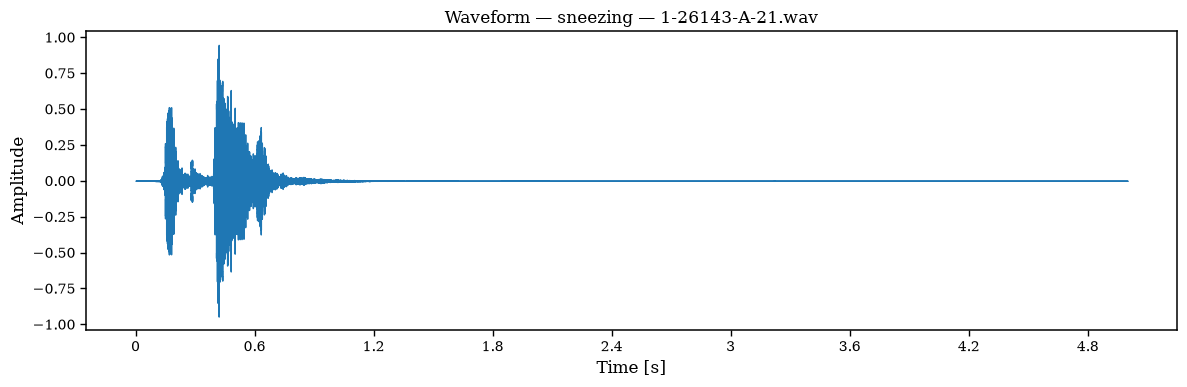

In [178]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Linear-frequency spectrogram reminder

A standard STFT spectrogram represents energy across time and frequency using a linear frequency axis.

This means that equal distances on the vertical axis correspond to equal differences in Hertz.

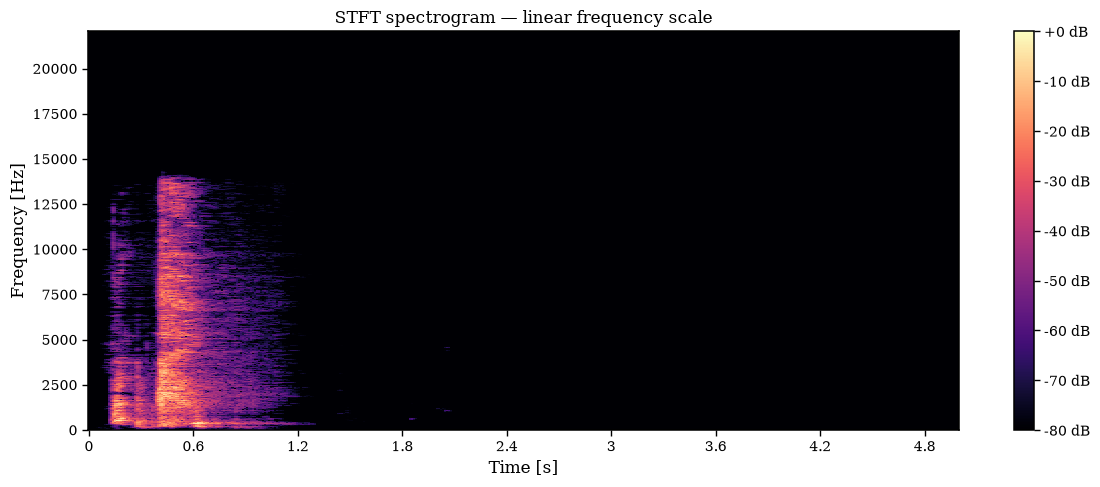

In [179]:
N_FFT = 2048
HOP_LENGTH = 512

S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title("STFT spectrogram — linear frequency scale")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

## Why move beyond a linear-frequency spectrogram?

A standard STFT spectrogram uses a linear frequency axis.  
This means that the spacing between 100 Hz and 200 Hz is visually the same as the spacing between 5000 Hz and 5100 Hz.

However, human pitch perception is not linear in Hz.  
At low frequencies, small differences in Hz are perceptually more salient than the same difference at high frequencies.

This motivates frequency scales and filter banks that are more closely related to auditory perception.

## Frequency, pitch, and the motivation for the mel scale

Before introducing the mel scale, it is useful to distinguish two related concepts: **frequency** and **pitch**.

**Frequency** is a physical quantity.  
It tells us how many oscillations per second a sound wave has, and it is measured in Hertz (Hz).

For example:

```text
200 Hz, 300 Hz, 3000 Hz, 3100 Hz
```

are physical frequencies.

**Pitch** is a perceptual attribute.  
It describes how high or low a sound is perceived by a listener.

In general:

```text
higher frequency → higher perceived pitch
lower frequency → lower perceived pitch
```

However, pitch perception is not perfectly linear with physical frequency.

For example, the physical difference between:

```text
200 Hz → 300 Hz
```

and:

```text
3000 Hz → 3100 Hz
```

is the same:

```text
100 Hz
```

But these two differences are not usually perceived as equally large changes in pitch.

The **mel scale** is a perceptual frequency scale designed to better reflect how humans perceive pitch differences.

A simplified intuition is:

```text
linear frequency scale → equal spacing in Hertz
mel scale → spacing closer to human pitch perception
```

In many audio machine learning tasks, mel-spectrograms are preferred because they provide a compact and perceptually meaningful representation of spectral content.


## Listening experiment: equal differences in Hz are not perceived equally

Before looking at mel filters, we can do a simple listening experiment.

Human **pitch perception** does not follow physical frequency differences in a perfectly linear way.  
A difference of 100 Hz at low frequencies can sound more noticeable than a difference of 100 Hz at high frequencies.

We will compare two pairs of pure tones:

```text
200 Hz → 300 Hz       difference = 100 Hz
3000 Hz → 3100 Hz     difference = 100 Hz
```

Both pairs have the same absolute frequency difference in Hertz.

However, the perceived pitch change is usually stronger in the low-frequency pair.

Before listening:

- Keep the volume low.
- Avoid loud playback.
- High-frequency tones can be uncomfortable for some listeners.


In [180]:
def generate_tone(frequency_hz, duration_s=1.0, sampling_rate=22050, amplitude=0.2):
    """
    Generate a pure sinusoidal tone.
    """
    t = np.arange(0, duration_s, 1 / sampling_rate)
    tone = amplitude * np.sin(2 * np.pi * frequency_hz * t)
    return tone, sampling_rate


def concatenate_tone_pair(
    f1,
    f2,
    duration_s=1.0,
    silence_s=0.4,
    sampling_rate=22050,
    amplitude=0.2,
):
    """
    Concatenate two pure tones separated by a short silence.
    """
    tone_1, sr_tone = generate_tone(f1, duration_s, sampling_rate, amplitude)
    tone_2, sr_tone = generate_tone(f2, duration_s, sampling_rate, amplitude)
    silence = np.zeros(int(silence_s * sr_tone))

    pair = np.concatenate([tone_1, silence, tone_2])
    return pair, sr_tone


In [181]:
low_frequency_pair, sr_tone = concatenate_tone_pair(200, 300)

print("Low-frequency pair: 200 Hz → 300 Hz")
print("Absolute difference:", 300 - 200, "Hz")

display(Audio(low_frequency_pair, rate=sr_tone))


Low-frequency pair: 200 Hz → 300 Hz
Absolute difference: 100 Hz


In [182]:
high_frequency_pair, sr_tone = concatenate_tone_pair(3000, 3100)

print("High-frequency pair: 3000 Hz → 3100 Hz")
print("Absolute difference:", 3100 - 3000, "Hz")

display(Audio(high_frequency_pair, rate=sr_tone))


High-frequency pair: 3000 Hz → 3100 Hz
Absolute difference: 100 Hz


### Listening question

Both tone pairs are separated by exactly 100 Hz.

```text
200 Hz → 300 Hz       difference = 100 Hz
3000 Hz → 3100 Hz     difference = 100 Hz
```

Which pair sounds more different?

This experiment illustrates that equal differences in Hertz are not necessarily perceived as equal differences in pitch.

This is one motivation for using perceptual frequency scales such as the mel scale.


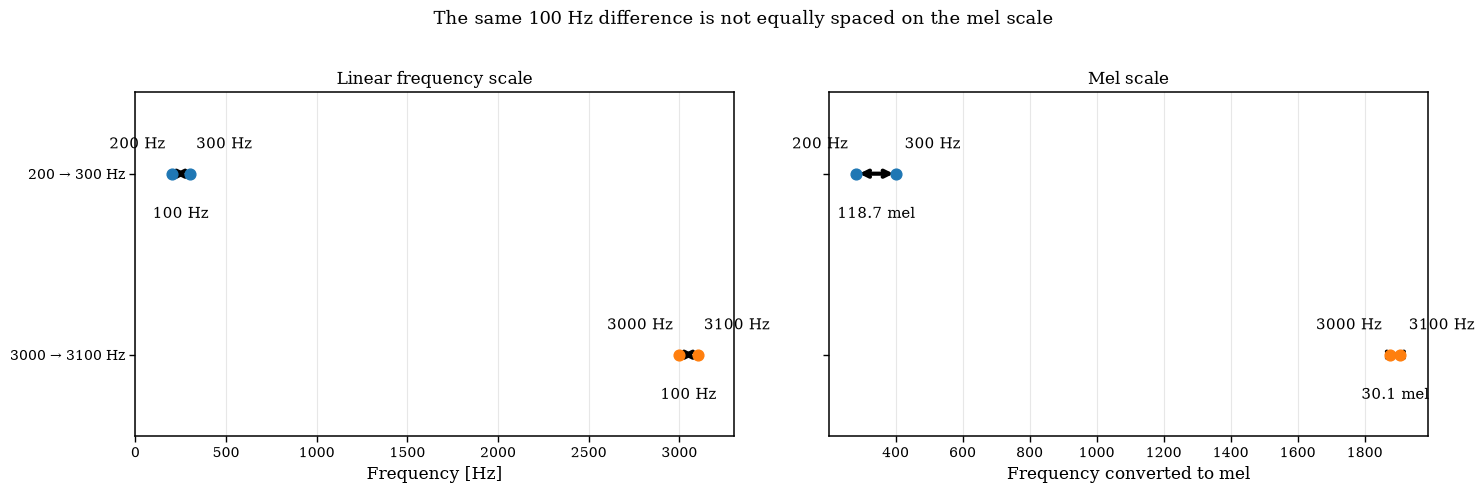

In [183]:
def hz_to_mel(frequency_hz):
    """
    Convert frequency in Hz to the mel scale using the common HTK formula.
    """
    return 2595 * np.log10(1 + frequency_hz / 700)


tone_pairs = [
    {
        "name": "Low-frequency pair",
        "pair_label": "200 → 300 Hz",
        "f1": 200,
        "f2": 300,
        "y": 1,
    },
    {
        "name": "High-frequency pair",
        "pair_label": "3000 → 3100 Hz",
        "f1": 3000,
        "f2": 3100,
        "y": 0,
    },
]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)

# ------------------------------------------------------------
# Panel 1: Linear frequency scale
# ------------------------------------------------------------
ax = axes[0]

for pair in tone_pairs:
    f1 = pair["f1"]
    f2 = pair["f2"]
    y_pos = pair["y"]

    ax.annotate(
        "",
        xy=(f2, y_pos),
        xytext=(f1, y_pos),
        arrowprops=dict(arrowstyle="<->", linewidth=3),
    )
    ax.scatter([f1, f2], [y_pos, y_pos], s=60, zorder=3)

    # Endpoint labels are intentionally placed on opposite sides to avoid overlap.
    ax.text(f1 - 35, y_pos + 0.12, f"{f1} Hz", ha="right", va="bottom")
    ax.text(f2 + 35, y_pos + 0.12, f"{f2} Hz", ha="left", va="bottom")
    ax.text((f1 + f2) / 2, y_pos - 0.18, "100 Hz", ha="center", va="top")

ax.set_title("Linear frequency scale")
ax.set_xlabel("Frequency [Hz]")
ax.set_yticks([0, 1])
ax.set_yticklabels(["3000 → 3100 Hz", "200 → 300 Hz"])
ax.set_ylim(-0.45, 1.45)
ax.set_xlim(0, 3300)
ax.grid(True, axis="x", alpha=0.3)

# ------------------------------------------------------------
# Panel 2: Mel scale
# ------------------------------------------------------------
ax = axes[1]

for pair in tone_pairs:
    f1 = pair["f1"]
    f2 = pair["f2"]
    y_pos = pair["y"]

    m1 = hz_to_mel(f1)
    m2 = hz_to_mel(f2)

    ax.annotate(
        "",
        xy=(m2, y_pos),
        xytext=(m1, y_pos),
        arrowprops=dict(arrowstyle="<->", linewidth=3),
    )
    ax.scatter([m1, m2], [y_pos, y_pos], s=60, zorder=3)

    ax.text(m1 - 25, y_pos + 0.12, f"{f1} Hz", ha="right", va="bottom")
    ax.text(m2 + 25, y_pos + 0.12, f"{f2} Hz", ha="left", va="bottom")
    ax.text((m1 + m2) / 2, y_pos - 0.18, f"{m2 - m1:.1f} mel", ha="center", va="top")

ax.set_title("Mel scale")
ax.set_xlabel("Frequency converted to mel")
ax.set_yticks([0, 1])
ax.set_yticklabels(["3000 → 3100 Hz", "200 → 300 Hz"])
ax.set_ylim(-0.45, 1.45)
ax.grid(True, axis="x", alpha=0.3)

fig.suptitle(
    "The same 100 Hz difference is not equally spaced on the mel scale",
    y=1.02,
)
plt.tight_layout()
plt.show()


### Interpreting the figure

The left panel shows the two tone pairs on a **linear frequency scale** in Hertz.

Both pairs are separated by exactly 100 Hz:

```text
200 Hz → 300 Hz
3000 Hz → 3100 Hz
```

On the linear scale, both intervals have the same physical size: 100 Hz.

The right panel shows the same tones after converting frequency to the **mel scale**.

In both cases, the physical frequency difference is the same: 100 Hz.
However, after converting to the mel scale, the low-frequency pair has a larger perceptual distance than the high-frequency pair.

In other words, on the mel scale, the low-frequency interval becomes larger than the high-frequency interval. This reflects the idea that a 100 Hz difference at low frequencies is usually perceived as a larger pitch change than a 100 Hz difference at high frequencies.

### How to read this figure

The horizontal axis is the important axis in this figure.

In the left panel, the horizontal axis shows frequency in Hertz (Hz).  

In the right panel, the horizontal axis shows the same frequencies converted to the mel scale.

The vertical axis does not represent amplitude, time, or energy.  

It is only used to separate the two tone pairs visually:

```text
top row:     200 Hz → 300 Hz
bottom row:  3000 Hz → 3100 Hz

This motivates the use of mel filter banks:

- lower frequencies receive more perceptual resolution;
- higher frequencies receive less perceptual resolution;
- filters are narrower at low frequencies;
- filters become wider at high frequencies.


## Mel scale conversion

We can visualize how Hertz values are mapped to mel values.

This helps us see that the mel scale compresses high frequencies compared with a linear Hertz scale.

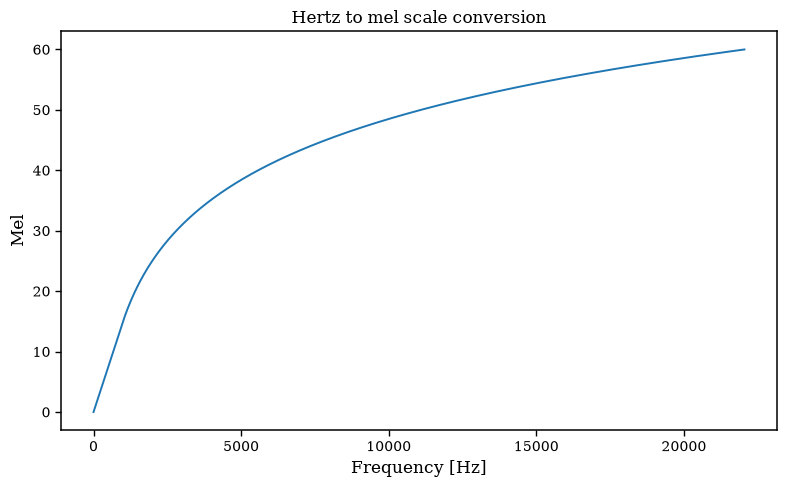

In [184]:
hz_values = np.linspace(0, sr / 2, 1000)
mel_values = librosa.hz_to_mel(hz_values)

plt.figure(figsize=(8, 5))
plt.plot(hz_values, mel_values)
plt.title("Hertz to mel scale conversion")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Mel")
plt.tight_layout()
plt.show()

## A bio-inspired intuition: frequency selectivity

The auditory system is **frequency selective**.

A useful way to explain this idea is:

> Different parts of the auditory system respond more strongly to different frequency regions.

This does **not** mean that the mel filter bank is a detailed biological model.  
Instead, the connection is conceptual and pedagogical:

```text
hearing is frequency selective
        ↓
audio analysis can also use frequency-selective channels
        ↓
filter banks summarize energy in different frequency bands
```

The mel filter bank is therefore a practical engineering representation inspired by perception, not a literal model of the ear.

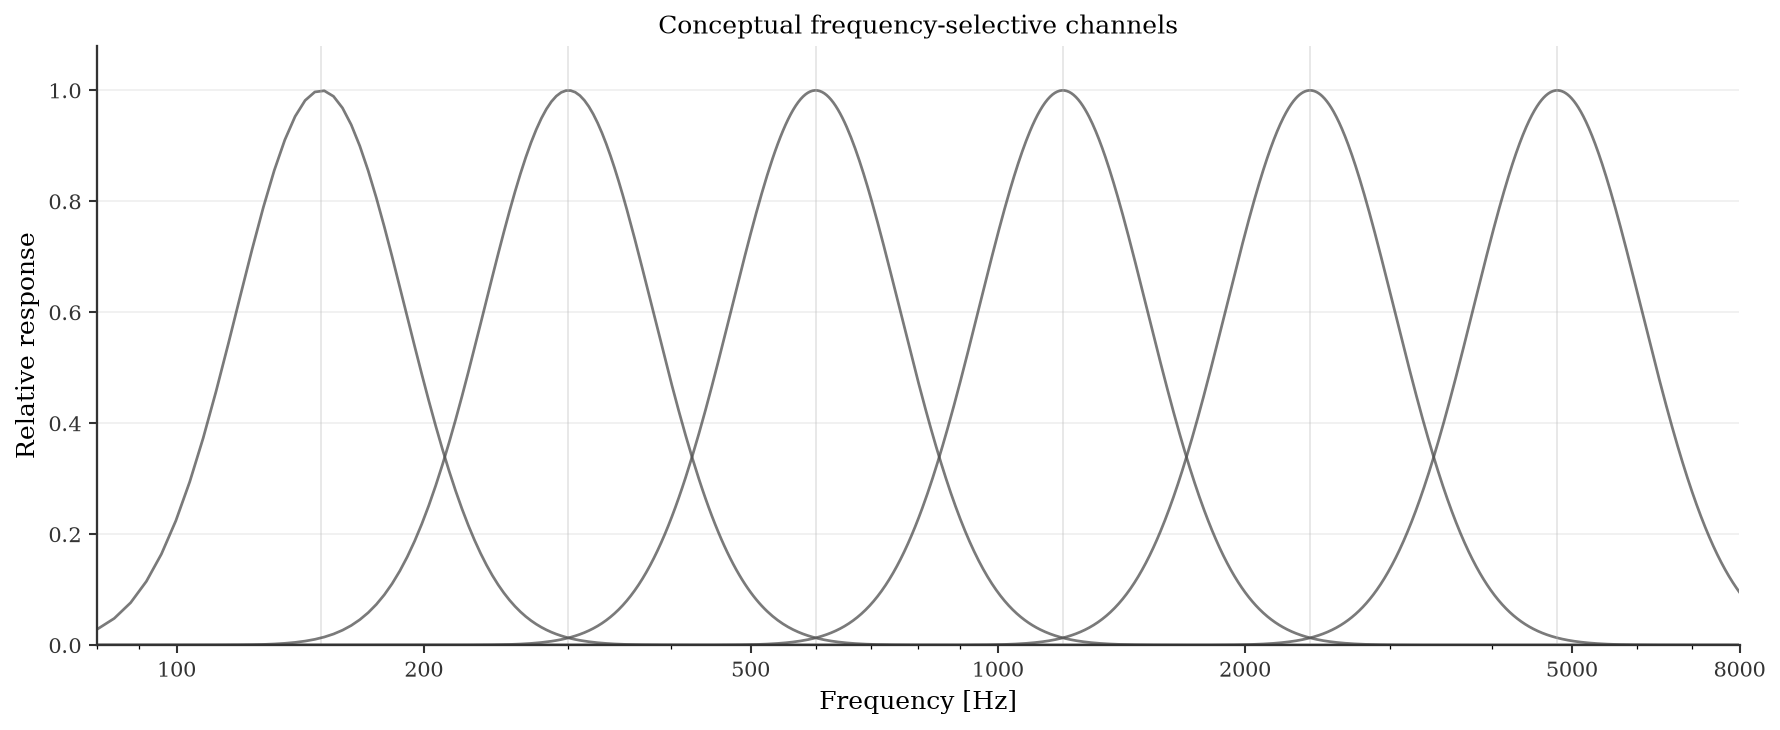

In [185]:
# auditory_frequency_selectivity_demo
# Conceptual figure inspired by frequency selectivity.
# This is not a physiological model; it is a pedagogical visualization.

conceptual_frequencies_hz = np.linspace(80, 8000, 2000)

# Characteristic frequencies used only for the conceptual illustration.
conceptual_cf_hz = np.array([150, 300, 600, 1200, 2400, 4800])

fig, ax = plt.subplots(figsize=FIGSIZE_TALL, dpi=DPI)

for cf in conceptual_cf_hz:
    # Use a constant bandwidth in log-frequency to mimic sharper tuning
    # on a perceptual/logarithmic frequency axis.
    log_distance = np.log2(conceptual_frequencies_hz / cf)
    bandwidth = 0.34
    response = np.exp(-0.5 * (log_distance / bandwidth) ** 2)

    ax.plot(
        conceptual_frequencies_hz,
        response,
        color=GRAYSCALE["secondary"],
        linewidth=1.3,
        alpha=0.75,
    )

    ax.axvline(
        cf,
        color=GRAYSCALE["light"],
        linewidth=0.8,
        alpha=0.35,
    )

ax.set_xscale("log")
ax.set_xlim(80, 8000)
ax.set_ylim(0, 1.08)

ax.set_title("Conceptual frequency-selective channels")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Relative response")

ax.set_xticks([100, 200, 500, 1000, 2000, 5000, 8000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()


### From frequency selectivity to filter banks

The previous figure illustrates a simple idea:

```text
each curve responds most strongly near one frequency region
```

A **filter bank** follows a related computational idea.  
Instead of describing an audio frame with every FFT bin separately, we summarize the spectrum using several overlapping frequency bands.

For audio data mining, this is useful because it transforms a detailed spectrum into a more compact representation:

```text
power spectrum
    ↓
filter bank
    ↓
energy per frequency band
```

The mel filter bank uses overlapping triangular filters distributed along the mel scale.  
This gives more detail at low frequencies and coarser detail at high frequencies, reflecting a perceptual motivation.

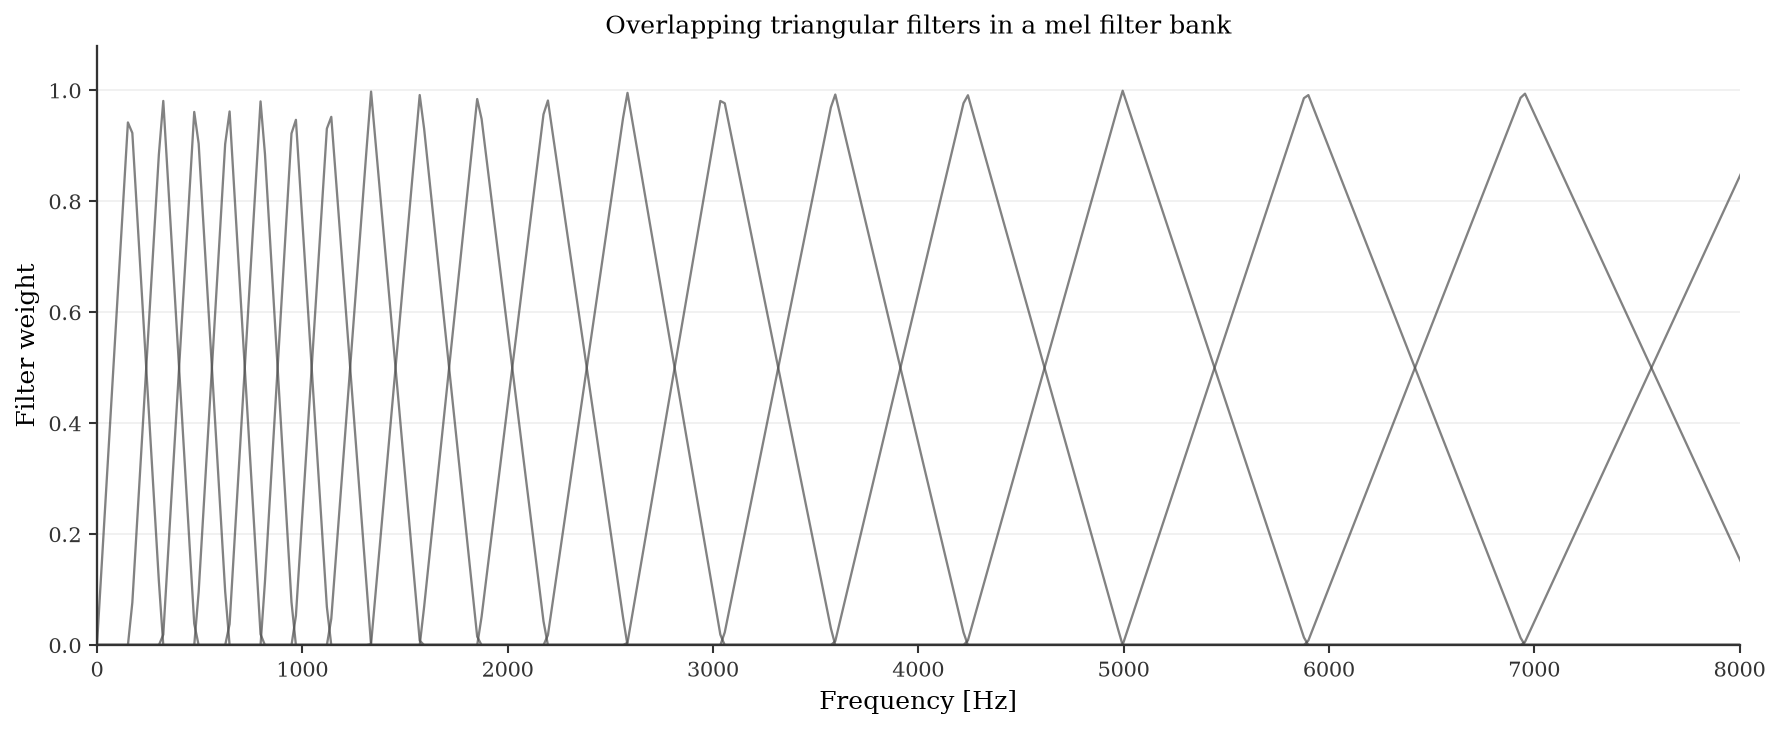

In [186]:
# Mel filter bank: overlapping triangular filters
#
# We use norm=None only for visualization.
# This makes all triangular filters have comparable height,
# which helps students see the overlapping structure more clearly.

N_FFT = 2048
N_MELS = 24

mel_filter_bank = librosa.filters.mel(
    sr=sr,
    n_fft=N_FFT,
    n_mels=N_MELS,
    fmin=0,
    fmax=sr / 2,
    norm=None,
)

fft_frequencies = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

fig, ax = plt.subplots(figsize=FIGSIZE_TALL, dpi=DPI)

for i in range(N_MELS):
    ax.plot(
        fft_frequencies,
        mel_filter_bank[i],
        color=GRAYSCALE["secondary"],
        alpha=0.70,
        linewidth=1.1,
    )

ax.set_title("Overlapping triangular filters in a mel filter bank")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Filter weight")
ax.set_xlim(0, 8000)
ax.set_ylim(0, 1.08)

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()

## Why are mel filters narrower at low frequencies and wider at high frequencies?

The listening experiment and the previous figure suggest that pitch perception is not based on equal differences in Hertz.

At low frequencies, small changes in Hertz can produce a relatively strong perceptual change.  
At high frequencies, the same absolute change in Hertz can sound much smaller.

For example:

```text
200 Hz → 300 Hz       difference = 100 Hz
3000 Hz → 3100 Hz     difference = 100 Hz
```

The difference is 100 Hz in both cases, but the first pair usually sounds more different.

A mel filter bank reflects this idea by allocating frequency resolution non-uniformly:

- at lower frequencies, filters are closer together and narrower;
- at higher frequencies, filters are farther apart and wider.

This gives more detail where human hearing is more sensitive to small pitch changes, and less detail where human hearing is less sensitive to small absolute differences in Hertz.

In short:

```text
linear frequency scale → equal spacing in Hz
mel scale → spacing inspired by human pitch perception
```

Therefore, a mel-spectrogram is not just a compressed spectrogram.  
It is a perceptually motivated time-frequency representation.


## What is a filter?

Before introducing mel filter banks, we need a simple idea from signal processing: the concept of a **filter**.

A **filter** is a tool that modifies a signal by emphasizing some frequency components and attenuating others.

A simple way to think about a filter is:

```text
input signal → filter → output signal
```

For example:

- a **low-pass filter** keeps low frequencies and attenuates high frequencies;
- a **high-pass filter** keeps high frequencies and attenuates low frequencies;
- a **band-pass filter** keeps frequencies within a certain frequency range and attenuates frequencies outside that range.

In audio analysis, filters help us focus on specific frequency regions of a sound.

For example, if a sound contains low, mid, and high frequency components, a filter can help us measure how much energy is present in one particular frequency region.


## What is a filter bank?

A **filter bank** is a collection of filters applied to the same signal or spectrum.

Instead of using only one filter, we use many filters, each one focused on a different frequency region.

A useful analogy is a graphic equalizer:

```text
low frequencies | mid frequencies | high frequencies
```

Each slider controls a different frequency band.

In a filter bank, each filter measures the energy in one frequency band.  
Together, the filters summarize how the signal energy is distributed across frequency.

We will first visualize a conceptual filter bank on a linear Hz axis.  
Then we will build a conceptual filter bank whose centers are equally spaced on the mel scale.


## A conceptual mel-spaced filter bank

We now build a simple conceptual filter bank whose centers are equally spaced on the mel scale.

This is not yet the real triangular mel filter bank used by `librosa`.  
It is a stepping stone that helps us understand why mel-spaced filters look non-uniform when plotted in Hz.

We will first look only at the **filter centers**, and then we will plot simple smooth filter shapes around those centers.

In [187]:
# Conceptual example of a filter bank with mel-spaced centers

def mel_to_hz(mel_value):
    """
    Convert mel value back to frequency in Hz using the inverse HTK formula.
    """
    return 700 * (10 ** (mel_value / 2595) - 1)


freqs = np.linspace(0, 8000, 1000)

n_filters = 8
min_freq = 0
max_freq = 8000

mel_min = hz_to_mel(min_freq)
mel_max = hz_to_mel(max_freq)

# Equally spaced points in the mel scale.
mel_edges = np.linspace(mel_min, mel_max, n_filters + 2)
mel_centers = mel_edges[1:-1]

# Convert mel-spaced centers and edges back to Hz.
hz_edges = mel_to_hz(mel_edges)
hz_centers = mel_to_hz(mel_centers)

# Local bandwidths are estimated from neighboring edges.
bandwidths = hz_edges[2:] - hz_edges[:-2]

mel_filter_table = pd.DataFrame({
    "filter_index": np.arange(1, n_filters + 1),
    "center_mel": mel_centers,
    "center_hz": hz_centers,
    "approx_bandwidth_hz": bandwidths,
})

mel_filter_table


,filter_index,center_mel,center_hz,approx_bandwidth_hz
0,1,315.558116,226.190660,525.470197
1,2,631.116233,525.470197,695.265127
2,3,946.674349,921.455786,919.925809
3,4,1262.232465,1445.396006,1217.180988
4,5,1577.790582,2138.636775,1610.488090
5,6,1893.348698,3055.884096,2130.884323
6,7,2208.906814,4269.521098,2819.435938
7,8,2524.464930,5875.320034,3730.478902


### First look only at the filter centers

Before looking at the full filter shapes, it is helpful to ignore the curves and look only at the **center positions**.

The filters below are designed with centers equally spaced in the mel scale.

The next figure shows the **same centers** in two ways:

```text
top panel    → center positions shown in Hz
bottom panel → center positions shown in mel
```

This makes the main idea visually clear:

> Equal spacing in mel becomes non-uniform spacing when viewed in Hz.

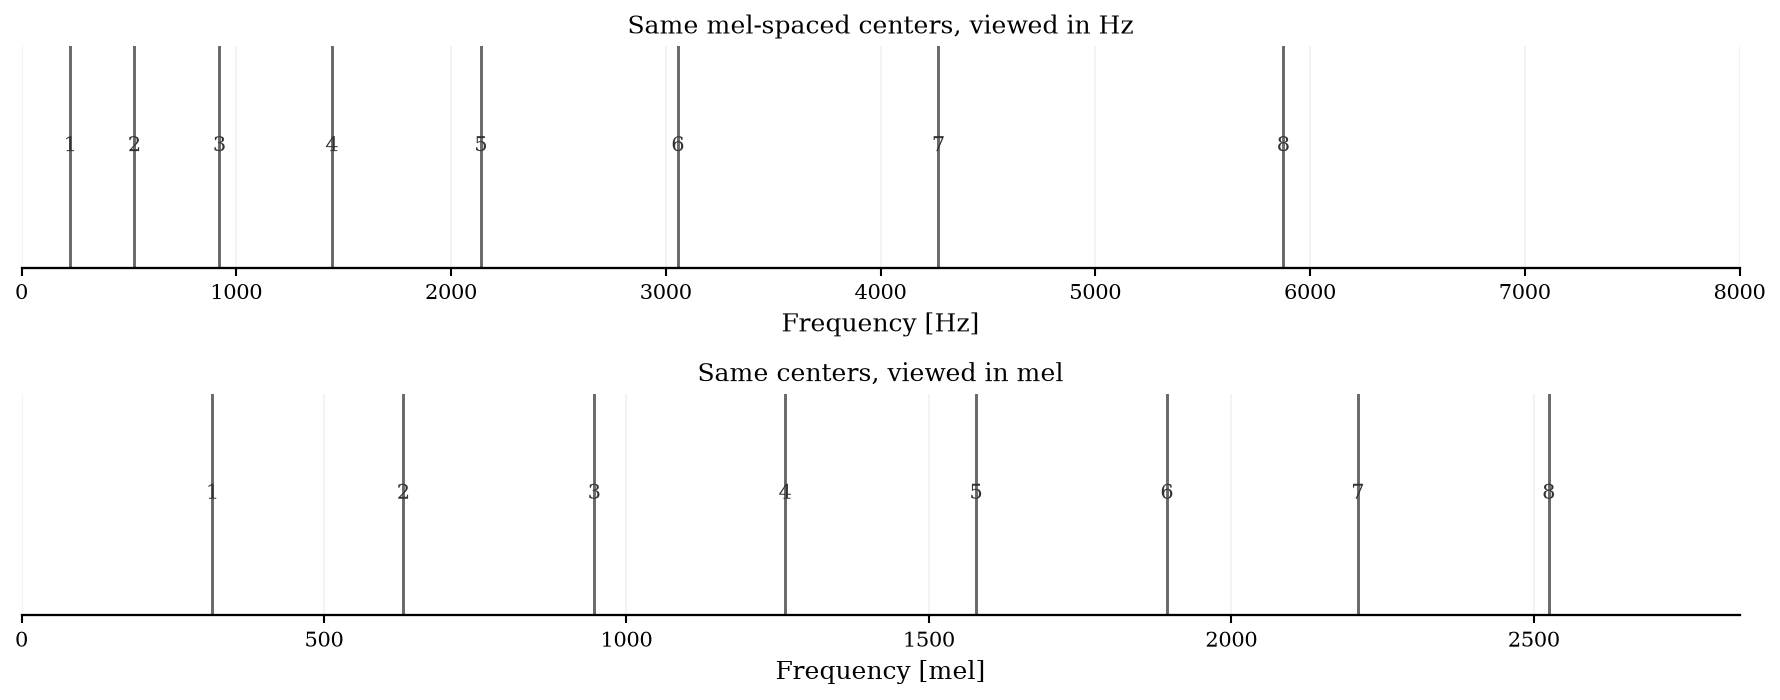

,filter_index,center_mel,center_hz,distance_to_previous_center_hz
0,1,315.558116,226.190660,NaN
1,2,631.116233,525.470197,299.279538
2,3,946.674349,921.455786,395.985589
3,4,1262.232465,1445.396006,523.940220
4,5,1577.790582,2138.636775,693.240769
5,6,1893.348698,3055.884096,917.247321
6,7,2208.906814,4269.521098,1213.637002
7,8,2524.464930,5875.320034,1605.798936


In [188]:
# center_spacing_demo_same_centers_two_axes
# Same mel-spaced centers shown on two different axes.

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 4.8),
    dpi=DPI,
)

# --- Same centers shown in Hz ---
ax = axes[0]

for idx, center_hz in enumerate(hz_centers, start=1):
    ax.axvline(
        center_hz,
        color=GRAYSCALE["secondary"],
        linewidth=1.4,
        alpha=0.85,
    )
    ax.text(
        center_hz,
        0.55,
        str(idx),
        ha="center",
        va="center",
        fontsize=10,
        color=GRAYSCALE["dark"],
    )

ax.set_title("Same mel-spaced centers, viewed in Hz")
ax.set_xlim(0, 8000)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Frequency [Hz]")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(True, axis="x", alpha=0.18)

# --- Same centers shown in mel ---
ax = axes[1]

for idx, center_mel in enumerate(mel_centers, start=1):
    ax.axvline(
        center_mel,
        color=GRAYSCALE["secondary"],
        linewidth=1.4,
        alpha=0.85,
    )
    ax.text(
        center_mel,
        0.55,
        str(idx),
        ha="center",
        va="center",
        fontsize=10,
        color=GRAYSCALE["dark"],
    )

ax.set_title("Same centers, viewed in mel")
ax.set_xlim(mel_min, mel_max)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Frequency [mel]")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(True, axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

center_spacing_table = pd.DataFrame({
    "filter_index": np.arange(1, n_filters + 1),
    "center_mel": mel_centers,
    "center_hz": hz_centers,
    "distance_to_previous_center_hz": np.r_[np.nan, np.diff(hz_centers)],
})

center_spacing_table

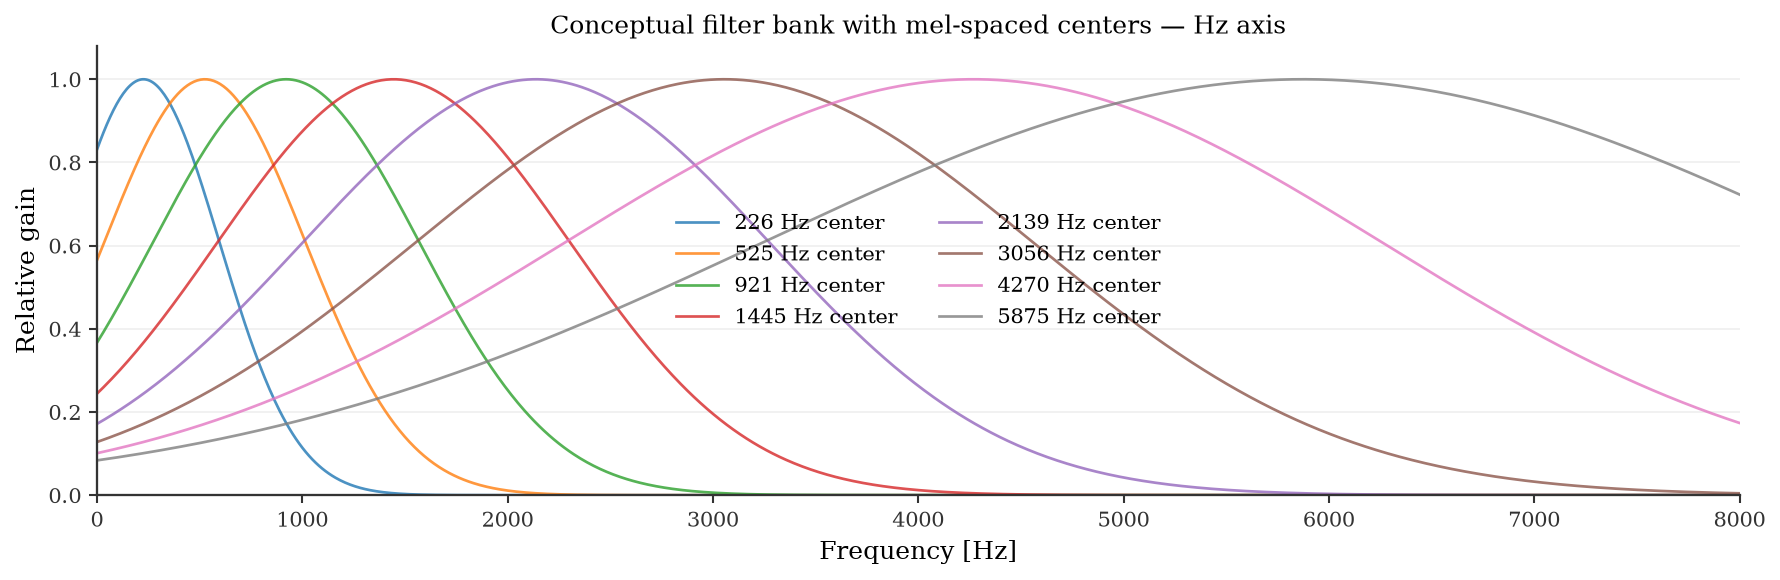

In [189]:
# Conceptual filter bank with mel-spaced centers, plotted in Hz

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

for center, bandwidth in zip(hz_centers, bandwidths):
    filter_response = np.exp(-((freqs - center) / bandwidth) ** 2)

    ax.plot(
        freqs,
        filter_response,
        linewidth=1.3,
        alpha=0.80,
        label=f"{center:.0f} Hz center",
    )

ax.set_title("Conceptual filter bank with mel-spaced centers — Hz axis")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Relative gain")
ax.set_xlim(0, 8000)
ax.set_ylim(0, 1.08)

clean_axes(ax, grid_axis="y")
ax.legend(ncol=2, loc="center", frameon=False)

plt.tight_layout()
plt.show()

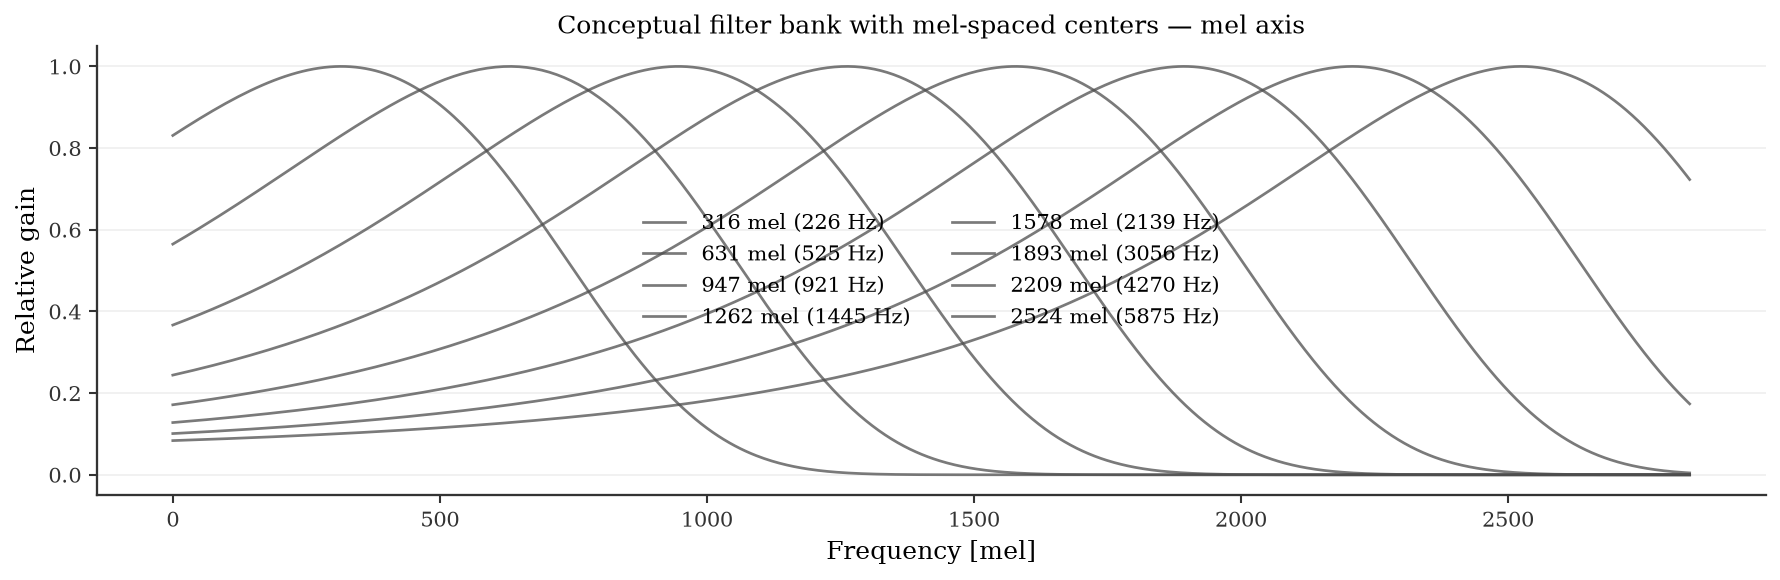

In [190]:
# Same conceptual filter bank, but plotted on the mel scale

mel_axis = hz_to_mel(freqs)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

for center_hz, center_mel, bandwidth_hz in zip(hz_centers, mel_centers, bandwidths):
    filter_response = np.exp(-((freqs - center_hz) / bandwidth_hz) ** 2)

    ax.plot(
        mel_axis,
        filter_response,
        linewidth=1.3,
        color=GRAYSCALE["secondary"],
        alpha=0.75,
        label=f"{center_mel:.0f} mel ({center_hz:.0f} Hz)",
    )

ax.set_title("Conceptual filter bank with mel-spaced centers — mel axis")
ax.set_xlabel("Frequency [mel]")
ax.set_ylabel("Relative gain")

clean_axes(ax, grid_axis="y")
ax.legend(ncol=2, loc="center", frameon=False)

plt.tight_layout()
plt.show()


### Interpretation

The key point is not the exact shape of the curves.  
The key point is where their centers are located.

We designed the filter centers to be equally spaced in the mel scale.  
When those same centers are plotted in mel, their spacing looks regular.  
When those same centers are converted back to Hz and plotted in Hz, they appear closer together at low frequencies and farther apart at high frequencies.

This happens because the mel scale is nonlinear with respect to Hz.

In short:

```text
uniform spacing in mel
        ↓
same centers viewed in Hz
        ↓
dense spacing at low frequencies
wide spacing at high frequencies
```

This is why mel filter banks provide more frequency detail at low frequencies and a coarser representation at high frequencies.

This prepares us to look at the real triangular mel filter bank used by `librosa`.

## What is a power spectrum?

When we apply the Fourier Transform to a signal, we obtain a complex-valued spectrum.

For a short audio frame, the Fourier Transform can be written as:

$
X[k]
$

where $k$ is the frequency-bin index.

Because $X[k]$ is complex-valued, it contains two types of information:

- **magnitude**, related to how much of each frequency is present (presence);
- **phase**, related to the alignment or timing of the sinusoidal components.

For many audio feature extraction tasks, we focus on the magnitude of the spectrum:

$
|X[k]|
$

The **power spectrum** is obtained by squaring the magnitude:

$
P[k] = |X[k]|^2
$

In simple terms:

```text
magnitude spectrum → how strong each frequency component is
power spectrum     → energy-like representation of each frequency component

### Transition to the real mel filter bank

The conceptual filters above help us understand the spacing.

We now move to the actual triangular mel filter bank generated by `librosa`.  
These filters are applied to the power spectrum of each short-time frame.

## Mel filter banks in practice

### Triangular mel filter bank

In practice, a mel-spectrogram is computed using a **bank of triangular filters**.

Each triangular filter emphasizes one mel band:

- frequencies near the center of the band receive higher weight;
- frequencies near the edges receive lower weight;
- frequencies outside the band receive zero or almost zero weight.

The filter bank transforms the original FFT frequency bins into a smaller number of mel-frequency bands.

In matrix form, this can be understood as:

$
\text{mel spectrum} = \text{mel filter bank} \times \text{power spectrum}
$

where:

- the power spectrum is defined on linear frequency bins in Hz;
- the mel filter bank contains triangular weighting functions;
- the output is a compact representation on the mel scale.

In [191]:
N_MELS = 64

mel_filter_bank = librosa.filters.mel(
    sr=sr,
    n_fft=N_FFT,
    n_mels=N_MELS,
    fmin=0,
    fmax=sr / 2,
)

print("Mel filter bank shape:", mel_filter_bank.shape)

Mel filter bank shape: (64, 1025)


### Why does the mel filter bank have shape `(64, 1025)`?

The mel filter bank is a matrix.

```text
rows    → mel filters
columns → FFT frequency bins
values  → filter weights
```

In this notebook, we use:

```python
N_MELS = 64
N_FFT = 2048
```

The first dimension is straightforward:

```text
64 rows → 64 triangular mel filters
```

The second dimension comes from the number of frequency bins produced by the FFT.

A full FFT of length $N_{\mathrm{FFT}}$ produces $N_{\mathrm{FFT}}$ frequency values.  
However, for real-valued audio signals, the spectrum is symmetric: the negative-frequency part does not add new information.

Therefore, we usually keep only the non-negative frequency bins:

```text
0 Hz → Nyquist frequency
```

The Nyquist frequency is:

$
f_{\mathrm{Nyquist}} = \frac{f_s}{2}
$

For a real-valued FFT, the number of non-negative frequency bins is:

$
\frac{N_{\mathrm{FFT}}}{2} + 1
$

In this case:

$
\frac{2048}{2} + 1 = 1024 + 1 = 1025
$

The `+1` appears because we include both endpoints:

```text
bin 0       → 0 Hz
bin 1024    → Nyquist frequency
```

Therefore, the mel filter bank has shape:

$
64 \times 1025
$

or, in Python:

```python
mel_filter_bank.shape == (64, 1025)
```

This means that each of the 64 mel filters assigns one weight to each of the 1025 non-negative FFT frequency bins.

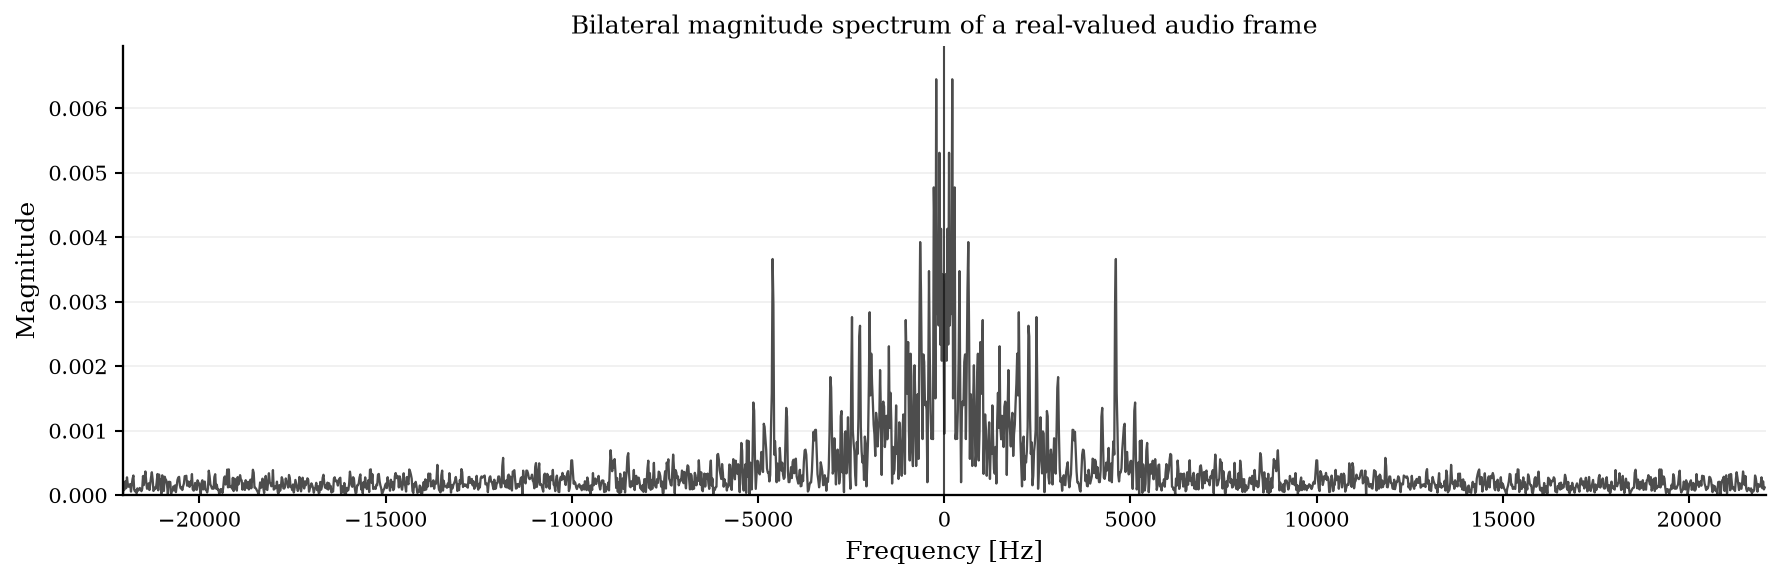

In [192]:
# Bilateral magnitude spectrum of a real-valued audio frame

frame_duration = 0.08  # seconds
frame_length = int(frame_duration * sr)

# Take a short frame from the audio signal.
start_sample = 0
end_sample = start_sample + frame_length

audio_frame = y[start_sample:end_sample]

# Apply a Hann window to reduce edge effects.
window = np.hanning(len(audio_frame))
windowed_frame = audio_frame * window

# Full FFT: includes positive and negative frequencies.
N_FFT = 2048
X_full = np.fft.fft(windowed_frame, n=N_FFT)
freqs_full = np.fft.fftfreq(N_FFT, d=1 / sr)

# Shift zero frequency to the center for visualization.
X_shifted = np.fft.fftshift(X_full)
freqs_shifted = np.fft.fftshift(freqs_full)

magnitude_shifted = np.abs(X_shifted)

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

ax.plot(
    freqs_shifted,
    magnitude_shifted,
    color="0.3",
    linewidth=1.1,
)

ax.axvline(0, color="0.1", linewidth=1.0, alpha=0.8)

ax.set_title("Bilateral magnitude spectrum of a real-valued audio frame")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Magnitude")

ax.set_xlim(-sr / 2, sr / 2)
ax.set_ylim(0, magnitude_shifted.max() * 1.08)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

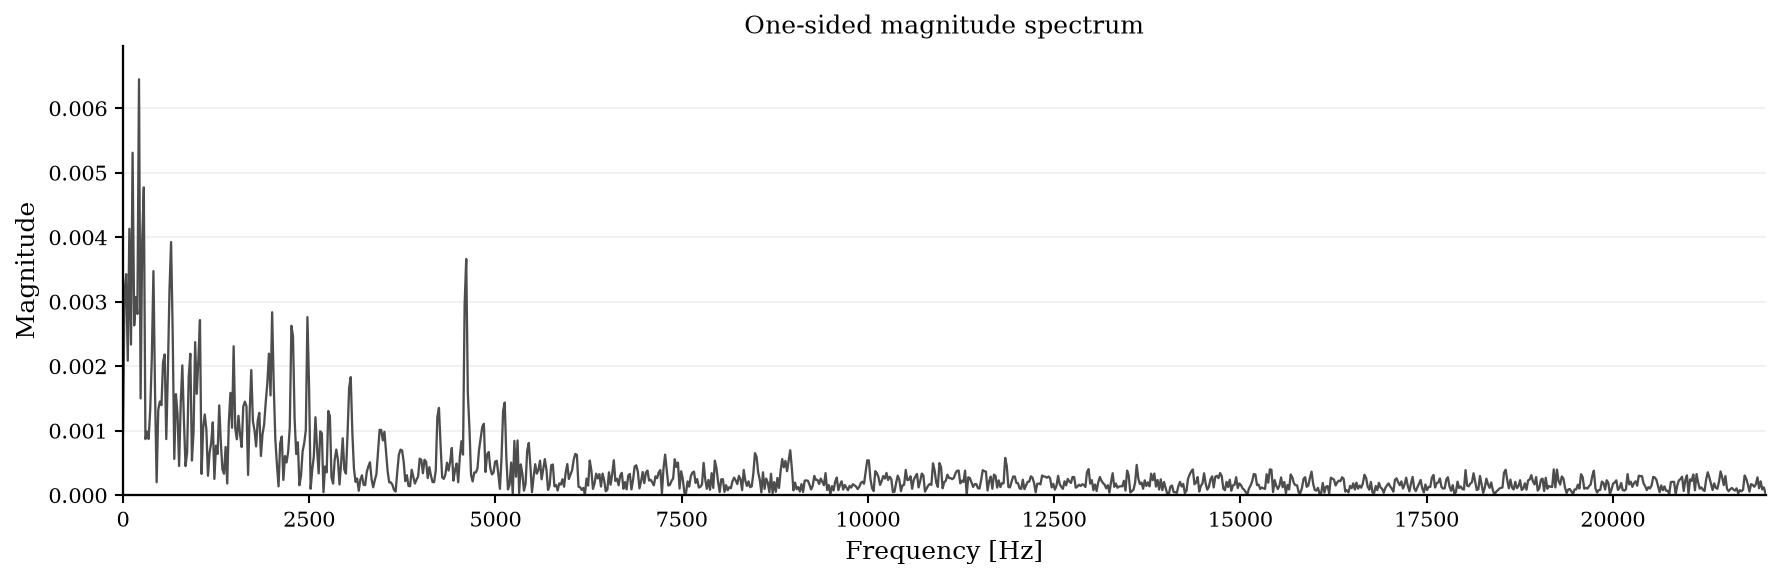

N_FFT: 2048
Full FFT bins: 2048
One-sided rFFT bins: 1025
N_FFT / 2 + 1: 1025


In [193]:
# One-sided magnitude spectrum using rFFT

X_one_sided = np.fft.rfft(windowed_frame, n=N_FFT)
freqs_one_sided = np.fft.rfftfreq(N_FFT, d=1 / sr)

magnitude_one_sided = np.abs(X_one_sided)

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

ax.plot(
    freqs_one_sided,
    magnitude_one_sided,
    color="0.3",
    linewidth=1.1,
)

ax.set_title("One-sided magnitude spectrum")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Magnitude")

ax.set_xlim(0, sr / 2)
ax.set_ylim(0, magnitude_one_sided.max() * 1.08)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

print("N_FFT:", N_FFT)
print("Full FFT bins:", len(X_full))
print("One-sided rFFT bins:", len(X_one_sided))
print("N_FFT / 2 + 1:", N_FFT // 2 + 1)

The full FFT contains both positive and negative frequencies.

For real-valued audio signals, the magnitude spectrum is symmetric:

$
|X(-f)| = |X(f)|
$

This means that the negative-frequency side does not add new magnitude information.  
For this reason, audio analysis commonly keeps only the non-negative frequencies:

```text
0 Hz → Nyquist frequency

In [194]:
print("N_FFT:", N_FFT)
print("N_MELS:", N_MELS)
print("Number of non-negative FFT frequency bins:", N_FFT // 2 + 1)
print("Mel filter bank shape:", mel_filter_bank.shape)

N_FFT: 2048
N_MELS: 64
Number of non-negative FFT frequency bins: 1025
Mel filter bank shape: (64, 1025)


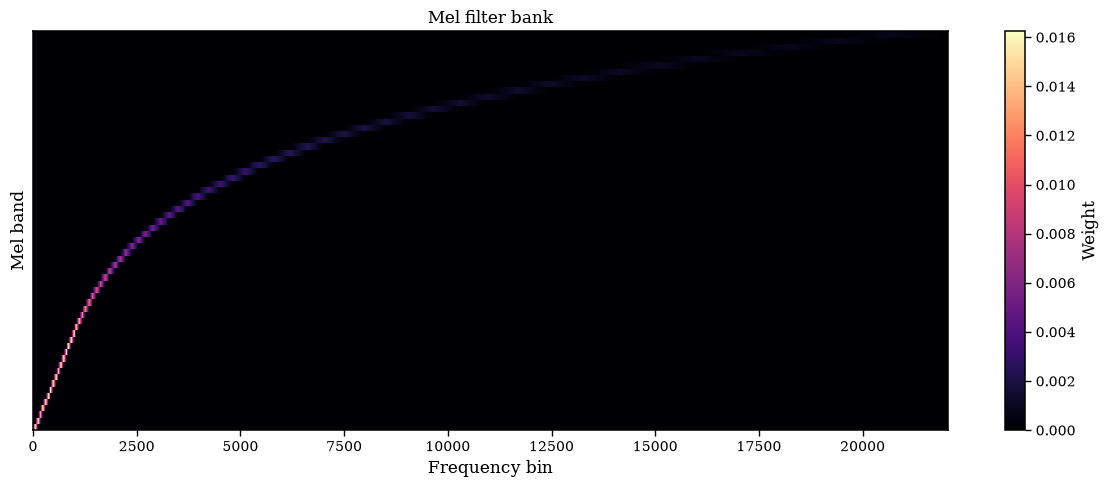

In [195]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_filter_bank,
    sr=sr,
    x_axis="linear",
)
plt.title("Mel filter bank")
plt.xlabel("Frequency bin")
plt.ylabel("Mel band")
plt.colorbar(label="Weight")
plt.tight_layout()
plt.show()

### Reading the triangular filters

The filters overlap because neighboring bands share part of the spectrum.  
At low frequencies, the filters are closer together, giving more frequency detail.  
At high frequencies, the filters become wider and more separated, giving a coarser representation.

In this visualization we used `norm=None` so that all filters have comparable height.  
This is useful pedagogically. In practical feature extraction, libraries may normalize the filters to balance the contribution of filters with different bandwidths.

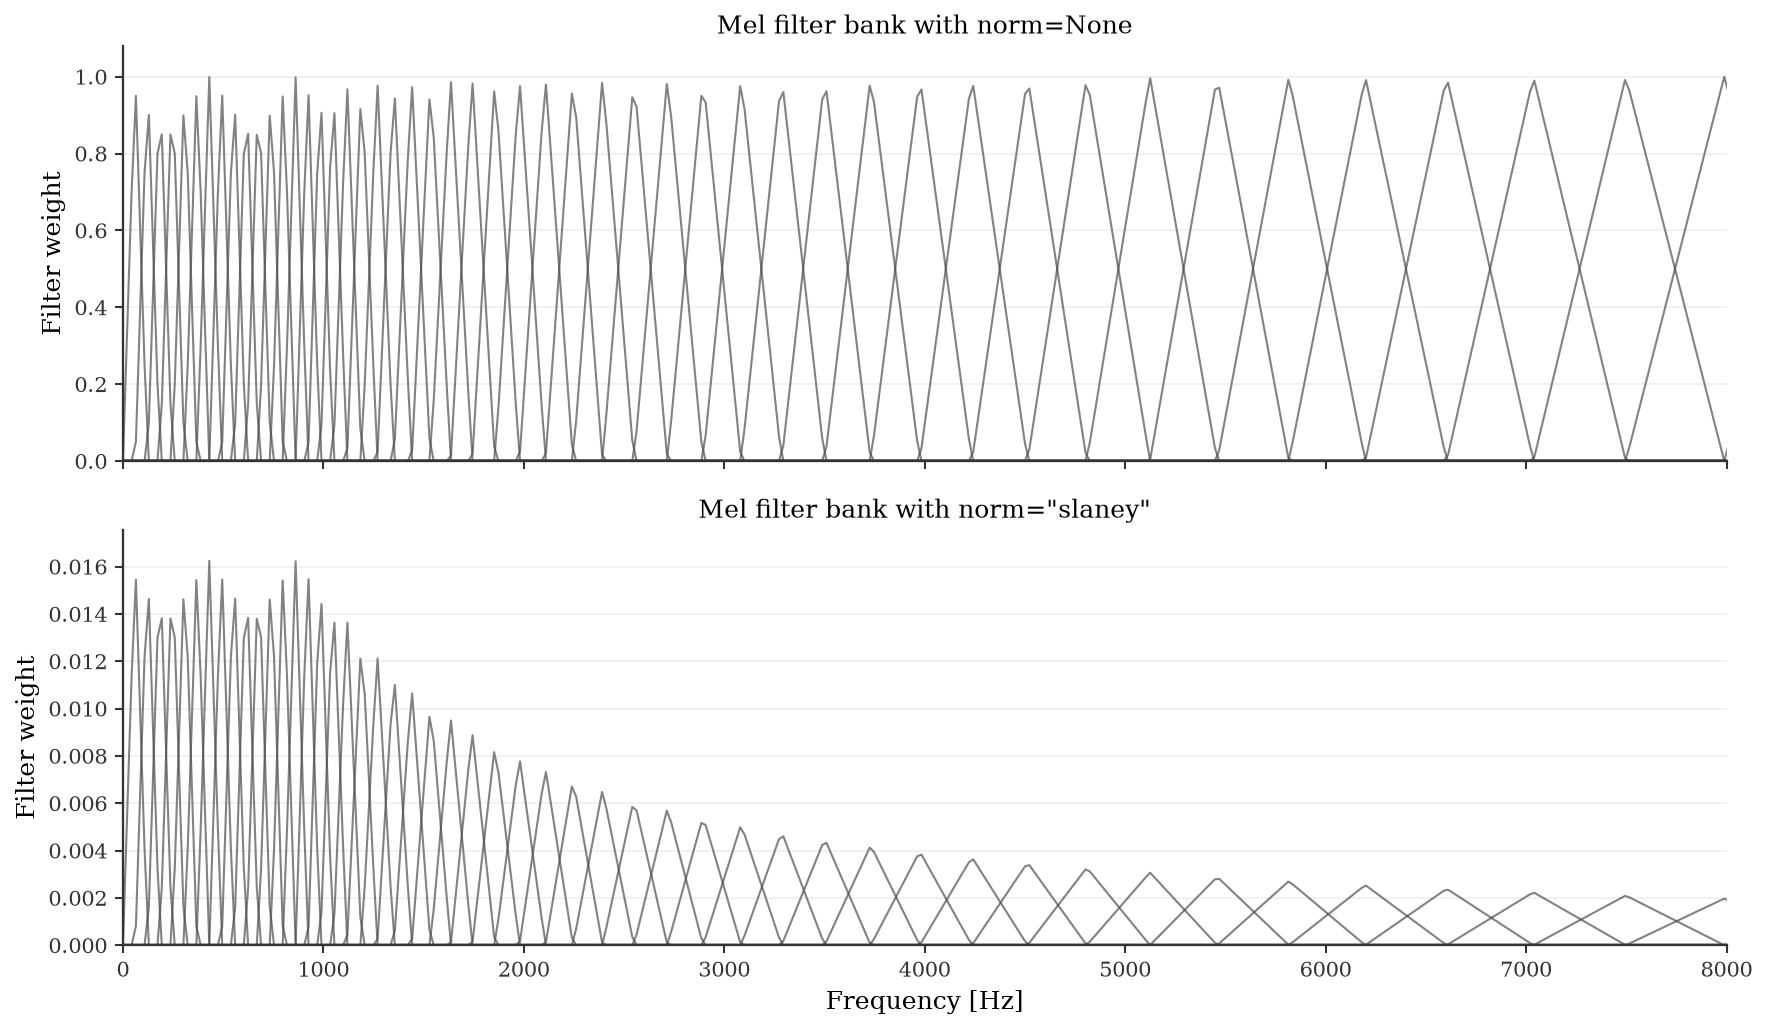

In [196]:
# Comparing mel filter bank normalization options
#
# We plot the two normalizations in separate panels because their
# vertical scales are very different.

N_FFT = 2048
N_MELS = 64

mel_filter_bank_none = librosa.filters.mel(
    sr=sr,
    n_fft=N_FFT,
    n_mels=N_MELS,
    fmin=0,
    fmax=sr / 2,
    norm=None,
)

mel_filter_bank_slaney = librosa.filters.mel(
    sr=sr,
    n_fft=N_FFT,
    n_mels=N_MELS,
    fmin=0,
    fmax=sr / 2,
    norm="slaney",
)

fft_frequencies = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    dpi=DPI,
    sharex=True,
)

# --- norm=None ---
ax = axes[0]

for i in range(N_MELS):
    ax.plot(
        fft_frequencies,
        mel_filter_bank_none[i],
        color=GRAYSCALE["secondary"],
        alpha=0.70,
        linewidth=1.0,
    )

ax.set_title("Mel filter bank with norm=None")
ax.set_ylabel("Filter weight")
ax.set_xlim(0, 8000)
ax.set_ylim(0, mel_filter_bank_none.max() * 1.08)

clean_axes(ax, grid_axis="y")

# --- norm="slaney" ---
ax = axes[1]

for i in range(N_MELS):
    ax.plot(
        fft_frequencies,
        mel_filter_bank_slaney[i],
        color=GRAYSCALE["secondary"],
        alpha=0.70,
        linewidth=1.0,
    )

ax.set_title('Mel filter bank with norm="slaney"')
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Filter weight")
ax.set_xlim(0, 8000)
ax.set_ylim(0, mel_filter_bank_slaney.max() * 1.08)

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()


### Reading the normalization comparison

With `norm=None`, all triangular filters have comparable peak height.  
This is useful for visualizing the geometry of the mel filter bank.

With `norm="slaney"`, filters are normalized according to their bandwidth.  
Because high-frequency filters are wider, their peak height becomes smaller.

The important point is that normalization changes the vertical scale of the filters, not their center frequencies or their overlapping structure.

## Mel-spectrogram

**IMPORTANT**: A mel-spectrogram represents the signal energy over time using mel-frequency bands instead of linearly spaced frequency bins.

Compared with the STFT spectrogram, it is usually more compact along the frequency axis.

In [197]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
)

print("Mel-spectrogram shape:", mel_spectrogram.shape)
print("Number of mel bands:", mel_spectrogram.shape[0])
print("Number of time frames:", mel_spectrogram.shape[1])

Mel-spectrogram shape: (64, 431)
Number of mel bands: 64
Number of time frames: 431


### What does padding mean?

In signal processing, **padding** means adding extra samples at the beginning or at the end of a signal.

For example, if a short signal is:

```text
[x0, x1, x2, x3, x4]
```

a zero-padded version could be:

```text
[0, 0, x0, x1, x2, x3, x4, 0, 0]
```

Padding does not create new information.  
It only extends the signal so that analysis windows can be placed near the boundaries.

In `librosa`, many time-frequency functions use:

```python
center=True
```

by default.

This means that each analysis frame is centered around its time position.  
To make this possible for the first and last frames, `librosa` pads the signal at the boundaries.

A useful intuition is:

```text
without padding → frames must stay fully inside the original signal
with padding    → frames can be centered near the beginning and end
```

This affects the number and alignment of time frames in the spectrogram.

In [198]:
# padding_demo_signal
# Small conceptual example: padding a short numerical signal.

padding_demo_signal = np.array([1, 2, 3, 4, 5])
padding_width = 2

padding_demo_padded = np.pad(
    padding_demo_signal,
    pad_width=padding_width,
    mode="constant",
    constant_values=0,
)

print("Original signal:")
print(padding_demo_signal)

print("\nZero-padded signal:")
print(padding_demo_padded)

Original signal:
[1 2 3 4 5]

Zero-padded signal:
[0 0 1 2 3 4 5 0 0]


### Why does the mel-spectrogram have 431 time frames?

The mel-spectrogram has shape:

```text
(64, 431)
```

This means:

```text
64  → mel-frequency bands
431 → time frames
```

The first dimension comes from:

```python
N_MELS = 64
```

The second dimension comes from how many short-time analysis frames are computed over the audio signal.

In this notebook, the audio signal has approximately 5 seconds.  
For ESC-50, the sampling rate is usually:

```text
sr = 44100 Hz
```

Therefore, a 5-second signal has approximately:

$
N = 5 \times 44100 = 220500
$

samples.

The STFT does not analyze all samples at once.  
Instead, it moves a window through the signal. The distance between consecutive analysis windows is controlled by:

```python
HOP_LENGTH = 512
```

This means that we compute one new time frame approximately every 512 samples.

With `librosa`, the default behavior is `center=True`. As explained above, this pads the signal at the boundaries so that frames can be centered near the beginning and end of the audio. In this common case, the number of time frames is:

$
n_{\mathrm{frames}} = 1 + \left\lfloor \frac{N}{\mathrm{hop\_length}} \right\rfloor
$

For this audio:

$n_{\mathrm{frames}} = 1 + \left\lfloor \frac{220500}{512} \right\rfloor
= 1 + 430 = 431$

Therefore, the mel-spectrogram has 431 columns:

```text
one column per analysis time frame
```

In short:

```text
N_MELS = 64       → 64 rows
HOP_LENGTH = 512 → 431 time frames for this 5-second audio
```

In [199]:
n_samples = len(y)
duration_seconds = n_samples / sr
estimated_frames = 1 + n_samples // HOP_LENGTH

print("Number of samples:", n_samples)
print("Sampling rate:", sr, "Hz")
print("Duration:", f"{duration_seconds:.2f}", "seconds")
print("Hop length:", HOP_LENGTH, "samples")
print("Estimated number of frames:", estimated_frames)
print("Mel-spectrogram shape:", mel_spectrogram.shape)

Number of samples: 220500
Sampling rate: 44100 Hz
Duration: 5.00 seconds
Hop length: 512 samples
Estimated number of frames: 431
Mel-spectrogram shape: (64, 431)


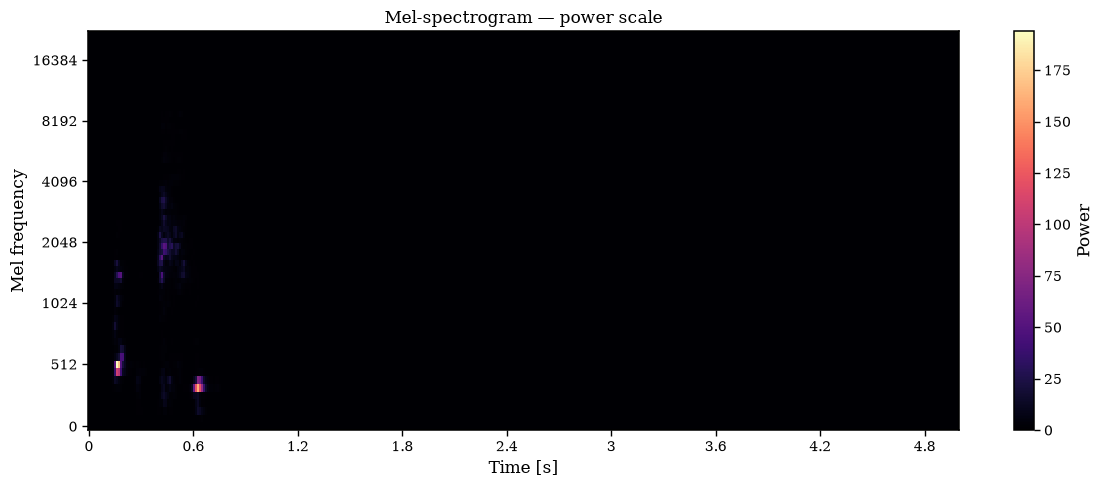

In [200]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_spectrogram,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(label="Power")
plt.title("Mel-spectrogram — power scale")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

### Improving the sneeze mel-spectrogram visualization

The previous figure is intentionally useful as a challenge.

The sneeze is a short and energetic event.  
In the **power scale**, a few high-energy regions dominate the color scale, and many weaker details become almost invisible.

This does not mean that there is no information in the rest of the signal.  
It means that **the dynamic range is large** (Higher-energy values ​​are easier to see than lower-energy values). 

A common solution in audio analysis is to convert the mel-spectrogram from power scale to decibel scale:

```text
power scale → dB scale
```

The dB scale compresses the dynamic range and makes weaker structures easier to see.

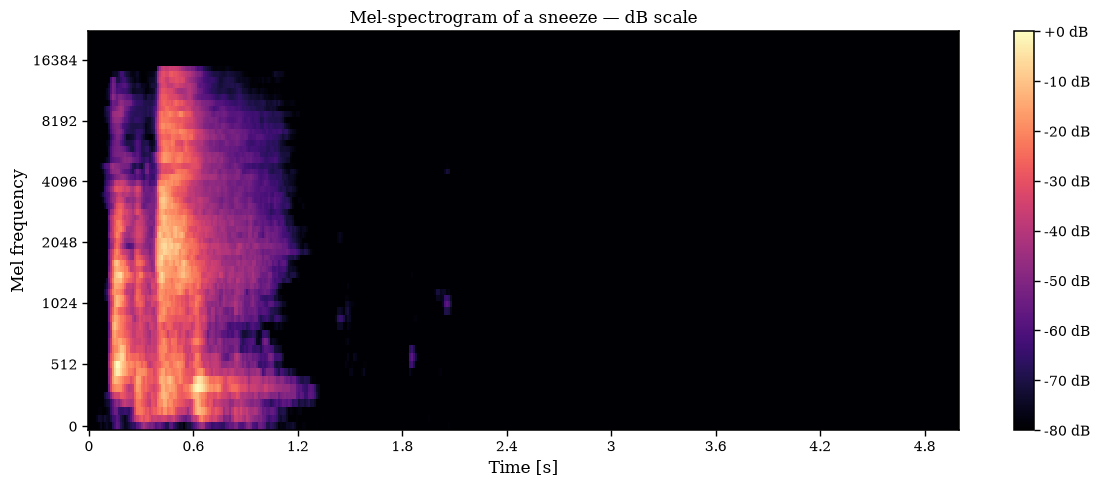

In [201]:
# Convert the mel-spectrogram from power scale to decibel scale

sneeze_mel_spectrogram_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max,
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    sneeze_mel_spectrogram_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-spectrogram of a sneeze — dB scale")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

### Why does the dB scale help?

In the power-scale figure, the strongest parts of the sneeze dominate the visualization.

The decibel scale applies a logarithmic compression.  
This reduces the dominance of the strongest values and makes lower-energy details easier to see.

This is one reason why audio spectrograms are commonly visualized in dB.

```text
power scale → useful for understanding absolute energy
dB scale    → useful for visualizing structure over a wide dynamic range
```

For teaching, it is useful to keep both figures:

1. the original power-scale version, where the visualization challenge appears;
2. the dB-scale version, where the hidden structure becomes clearer.

### A higher-resolution view of the sneeze

We can also improve the view by changing some analysis parameters.

For a short transient event such as a sneeze, we often want better time tracking.  
One way to do this is to reduce the hop length:

```text
smaller hop_length → more time frames → better temporal detail
```

We can also increase the number of mel bands and limit the frequency range to 8000 Hz:

```text
more mel bands → more detail along the mel-frequency axis
fmax = 8000 Hz → focus the representation on a useful audio range
```

Below, we keep the original power-scale figure as the starting challenge, and then compute a higher-resolution dB view.

Original mel-spectrogram shape: (64, 431)
Higher-resolution mel-spectrogram shape: (128, 862)


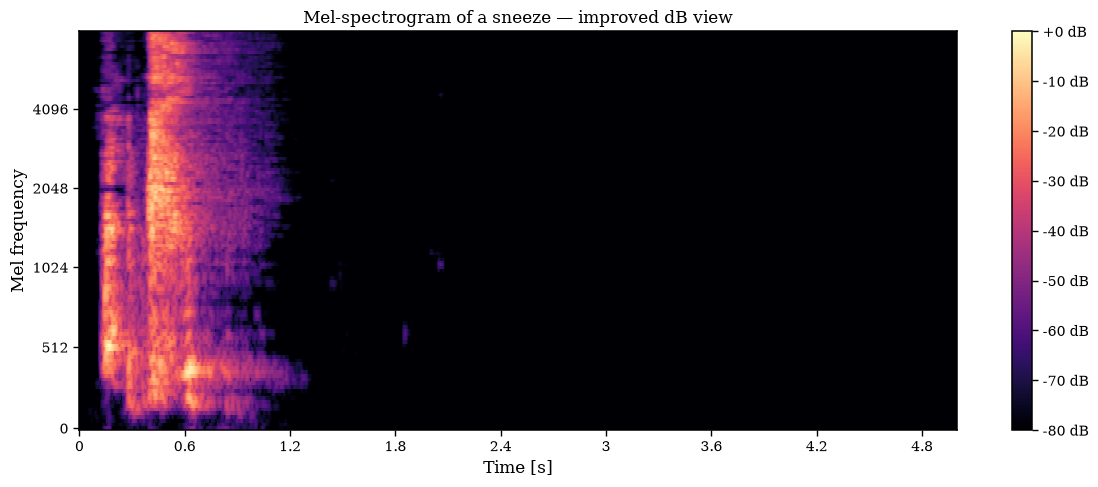

In [202]:
# Higher-resolution mel-spectrogram view for the sneeze

SNEEZE_N_FFT = 2048
SNEEZE_HOP_LENGTH = 256
SNEEZE_N_MELS = 128
SNEEZE_FMAX = 8000

sneeze_mel_spectrogram_hr = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=SNEEZE_N_FFT,
    hop_length=SNEEZE_HOP_LENGTH,
    n_mels=SNEEZE_N_MELS,
    fmin=0,
    fmax=SNEEZE_FMAX,
    power=2.0,
)

sneeze_mel_spectrogram_hr_db = librosa.power_to_db(
    sneeze_mel_spectrogram_hr,
    ref=np.max,
)

print("Original mel-spectrogram shape:", mel_spectrogram.shape)
print("Higher-resolution mel-spectrogram shape:", sneeze_mel_spectrogram_hr.shape)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    sneeze_mel_spectrogram_hr_db,
    sr=sr,
    hop_length=SNEEZE_HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmax=SNEEZE_FMAX,
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-spectrogram of a sneeze — improved dB view")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

### Interpretation

The improved view changes three things:

```text
1. dB scale compresses the dynamic range.
2. Smaller hop_length gives more time frames.
3. More mel bands give more vertical detail.
```

This is especially helpful for transient sounds.

A sneeze is short, energetic, and concentrated in time.  
Therefore, it is a good example for showing that visualization choices strongly affect what we can see in a spectrogram.

## Log-mel-spectrogram

Audio energy values often span a large numerical range.

For visualization and machine learning, it is common to convert the mel-spectrogram to a logarithmic decibel scale.

This produces the **log-mel-spectrogram**.

The log-mel representation is widely used in audio classification, speech processing, environmental sound analysis, and bioacoustics.

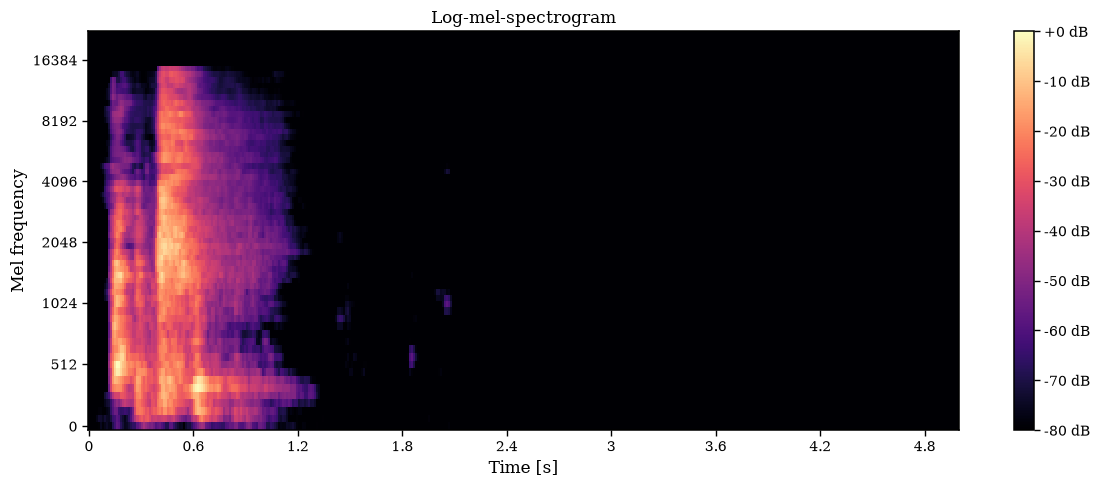

In [203]:
log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_mel_spectrogram,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-mel-spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

## STFT spectrogram versus log-mel-spectrogram

The STFT spectrogram and the log-mel-spectrogram represent related information, but with different frequency axes and scaling.

- The STFT spectrogram uses linearly spaced frequency bins.
- The log-mel-spectrogram uses perceptually motivated mel bands and decibel scaling.

The log-mel-spectrogram is often more compact and more useful as an input representation for machine learning.

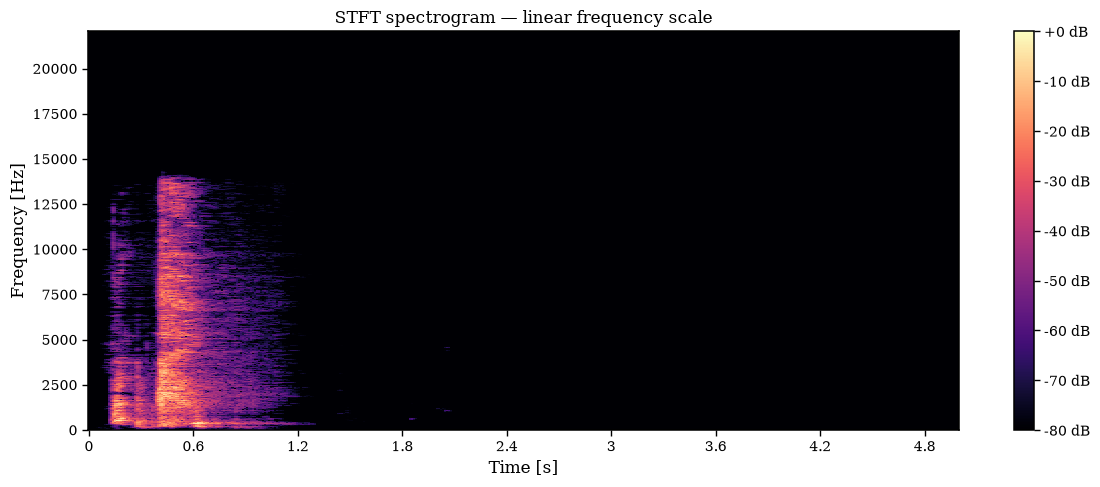

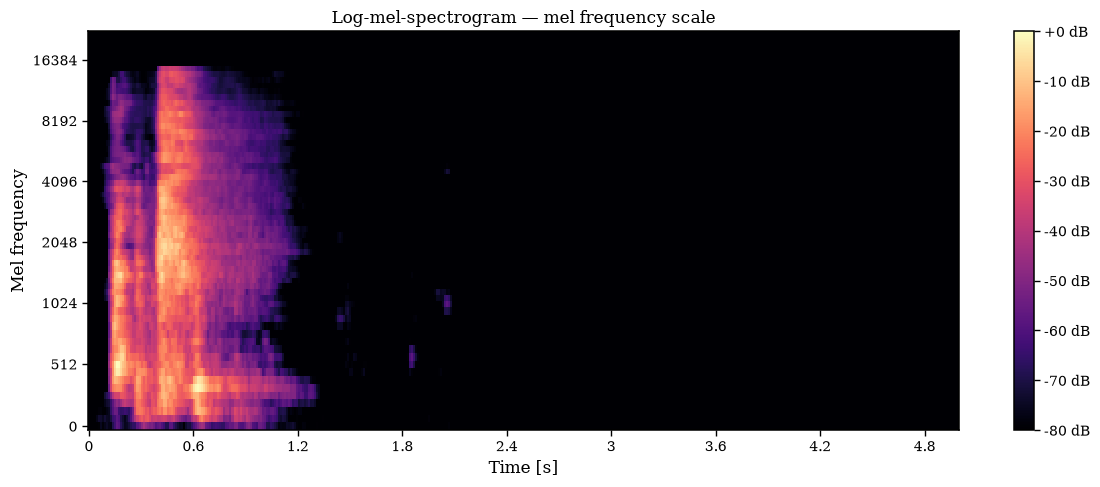

In [204]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title("STFT spectrogram — linear frequency scale")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_mel_spectrogram,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-mel-spectrogram — mel frequency scale")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

## Synthetic example: two pure tones

To make the mel representation easier to interpret, we create a synthetic signal with two pure tones.

This helps us see how tonal components appear in a log-mel-spectrogram.

In [205]:
synthetic_sr = 22050
synthetic_duration = 2.0

t = np.arange(0, synthetic_duration, 1 / synthetic_sr)

f1 = 440
f2 = 1760

synthetic_signal = 0.5 * np.sin(2 * np.pi * f1 * t) + 0.3 * np.sin(2 * np.pi * f2 * t)

print("Synthetic signal duration:", len(synthetic_signal) / synthetic_sr, "seconds")
print("Tone frequencies:", f1, "Hz and", f2, "Hz")

display(Audio(synthetic_signal, rate=synthetic_sr))

Synthetic signal duration: 2.0 seconds
Tone frequencies: 440 Hz and 1760 Hz


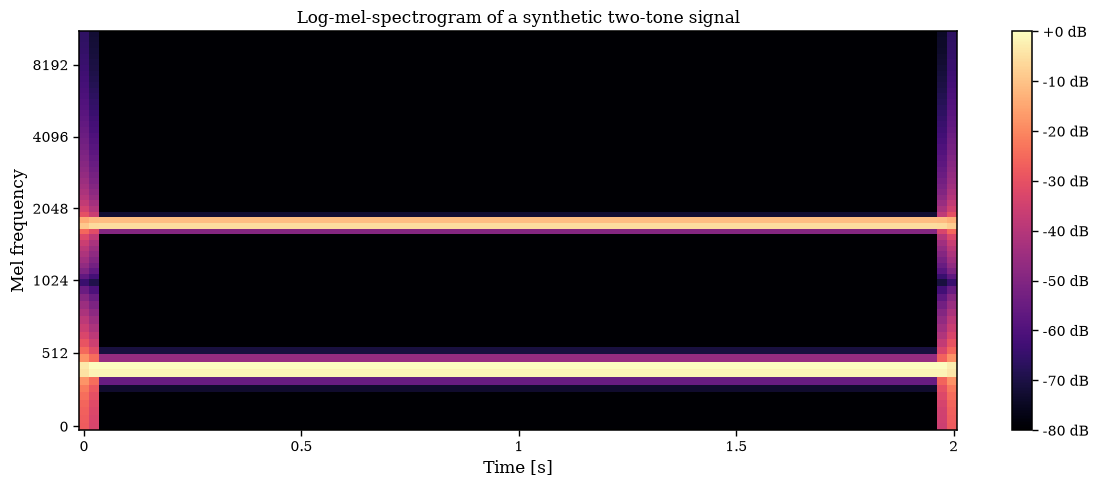

In [206]:
synthetic_mel = librosa.feature.melspectrogram(
    y=synthetic_signal,
    sr=synthetic_sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
)

synthetic_log_mel = librosa.power_to_db(synthetic_mel, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    synthetic_log_mel,
    sr=synthetic_sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-mel-spectrogram of a synthetic two-tone signal")
plt.xlabel("Time [s]")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

## Compare log-mel-spectrograms across sound classes

Now we compute log-mel-spectrograms for one example from several ESC-50 classes.

This allows us to visually compare how different sound categories appear in the mel time-frequency domain.

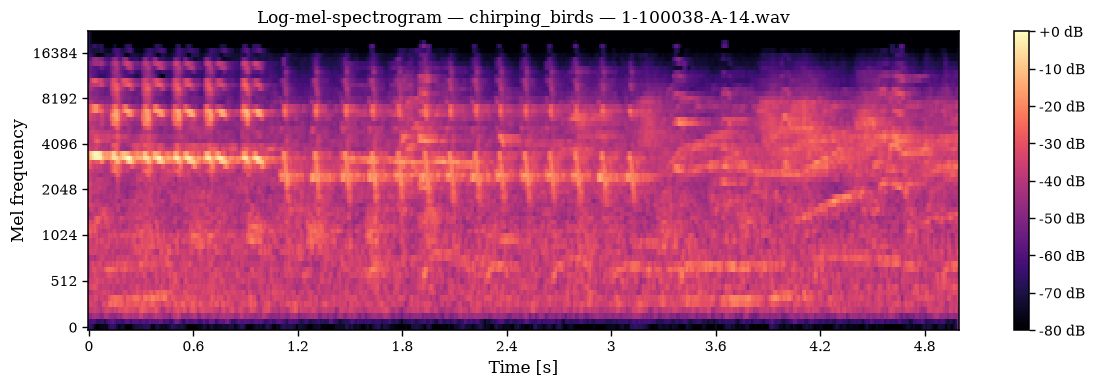

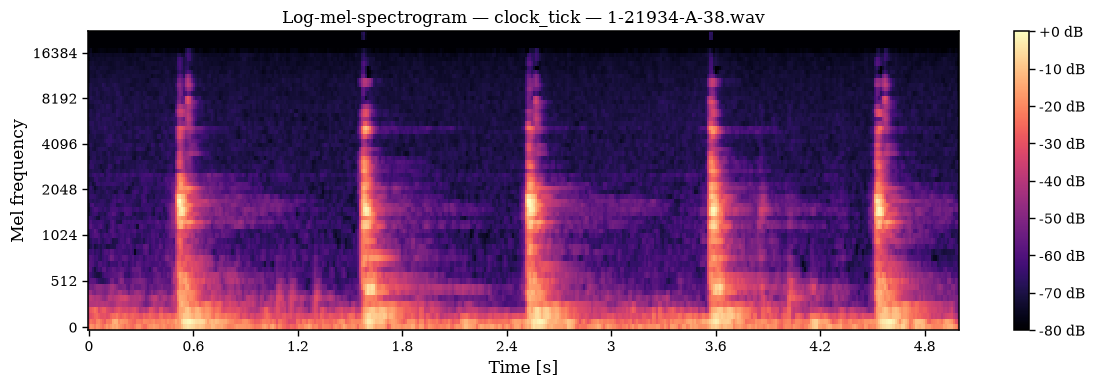

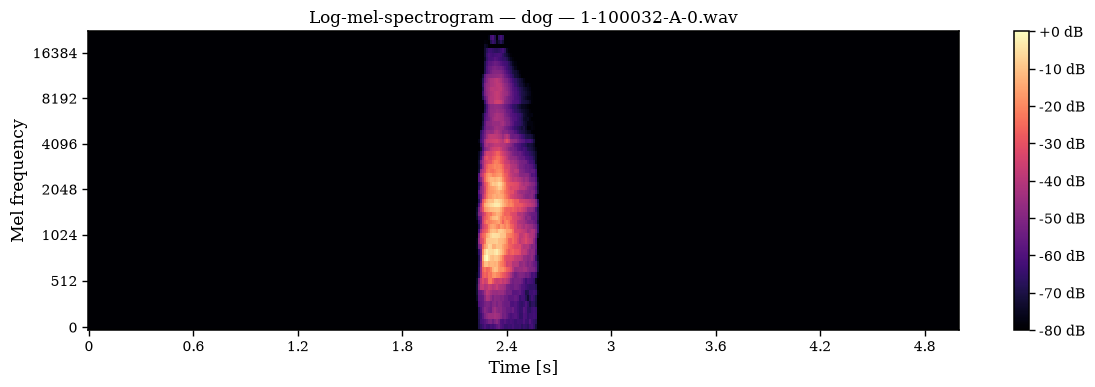

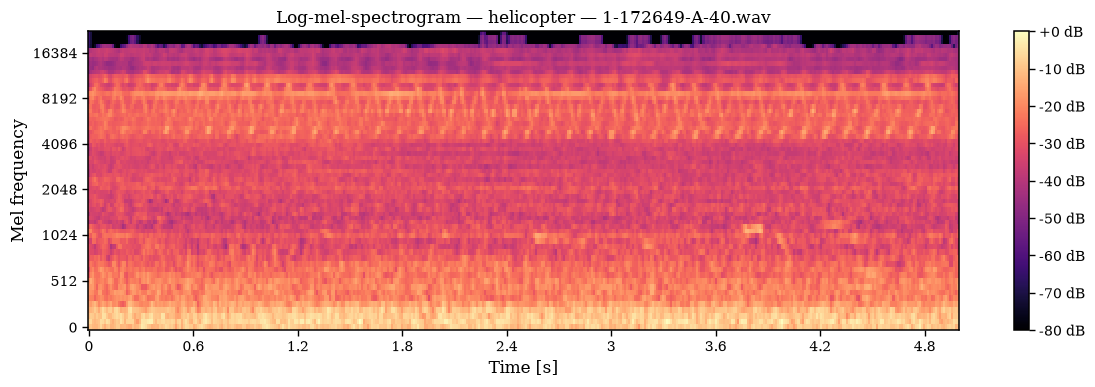

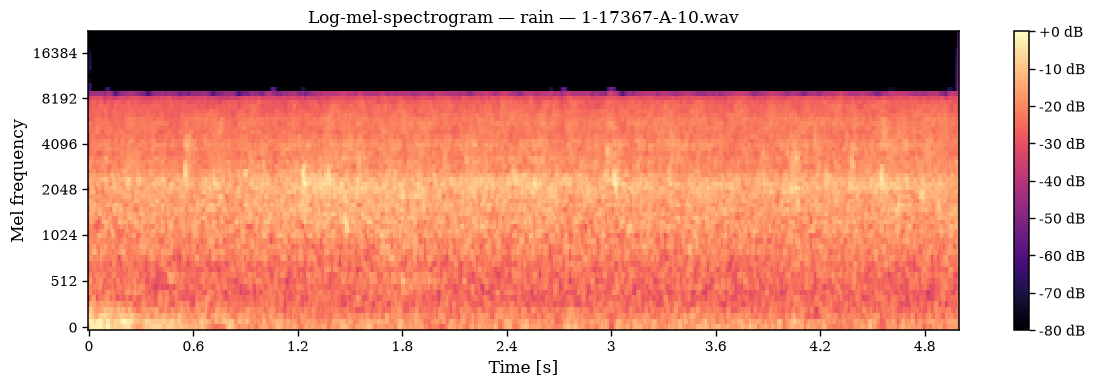

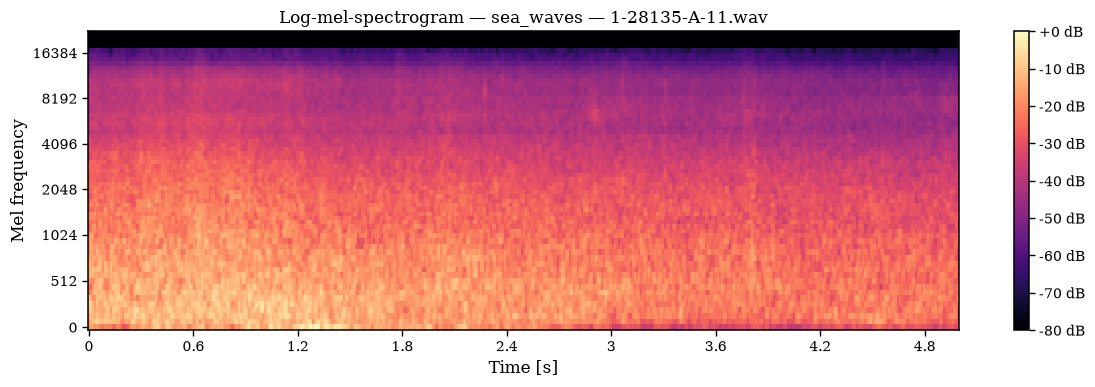

In [207]:
selected_categories = [
    "chirping_birds",
    "clock_tick",
    "dog",
    "helicopter",
    "rain",
    "sea_waves",
]

for category in selected_categories:
    row = metadata[metadata["category"] == category].iloc[0]
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    y_class, sr_class = librosa.load(audio_path, sr=None, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y_class,
        sr=sr_class,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        log_mel,
        sr=sr_class,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Log-mel-spectrogram — {category} — {row['filename']}")
    plt.xlabel("Time [s]")
    plt.ylabel("Mel frequency")
    plt.tight_layout()
    plt.show()

## Image-like representations for machine learning

A log-mel-spectrogram can be interpreted as an image-like representation:

- horizontal axis: time,
- vertical axis: mel-frequency bands,
- color: energy in decibels.

This is one reason why log-mel-spectrograms are commonly used as inputs for machine learning models.

However, in traditional data mining workflows, we may also summarize audio signals using numerical features.

This leads naturally to the next notebook.

## Optional extension

Some additional listening demonstrations with filter banks can be useful in a longer class, but they are not required for the main flow of this notebook.

The central path is:

```text
STFT spectrogram → mel filter bank → mel-spectrogram → log-mel representation
```

## Preview: from log-mel-spectrograms to MFCCs

MFCCs are compact audio features derived from the log-mel spectrum.

A simplified pipeline is:

```text
audio waveform
    ↓
STFT
    ↓
mel filter bank
    ↓
log amplitude
    ↓
DCT
    ↓
MFCC coefficients
```

In the next notebook, we will focus on feature extraction, including time-domain features, spectral features, and MFCCs.

## Discussion questions

1. What information is easier to see in a spectrogram than in a waveform?
2. What changes when we replace the linear frequency axis with the mel scale?
3. Why is the logarithmic decibel scale useful for visualizing audio energy?
4. Which ESC-50 classes show more continuous energy over time?
5. Which classes show more impulsive or short-duration events?
6. Why might log-mel-spectrograms be useful for machine learning?
7. What information might be lost when converting from a linear STFT spectrogram to a mel-spectrogram?